# Machine Learning Final Project - Phase 2 (Classification)

This notebook builds a clean and reproducible classification workflow for Phase 2 using the same dataset, preprocessing logic, and split strategy from Phase 1.

## 1. Imports and Configuration
Import required libraries and set plotting style.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

print('Imports loaded successfully.')

Imports loaded successfully.


## 2. Data Loading and Understanding
Load the same classification dataset used in Phase 1 and inspect its structure.

In [ ]:
DATA_PATH = 'classification/heart_disease.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())

print('Data types:')
display(df.dtypes)

print('Target distribution:')
display(df['target'].value_counts())

Dataset shape: 303 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Data types:


,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


Target distribution:


,count
target,
1,165
0,138


## 3. Phase 1 Preprocessing (Reused)
Apply the same preprocessing logic used in Phase 1:
- Handle missing values
- Cap outliers using IQR on the same numerical columns
- Keep the same feature setup

In [3]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print('Missing values before handling:')
display(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    for col in cat_features:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after handling:')
display(df.isnull().sum())

# Outlier capping using the same Phase 1 numerical columns
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lower, upper=upper)

print('Preprocessing complete.')

Missing values before handling:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Missing values after handling:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Preprocessing complete.


## 4. Train-Test Split and Scaling
Use the same split strategy from Phase 1 (test_size=0.2, random_state=42, stratify=y).

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (242, 13), Test shape: (61, 13)


## 5.1 KNN — Finding Optimal K
Test different values of K (1→20) and select the one with highest test accuracy.

Optimal K = 5  |  Accuracy = 0.8525


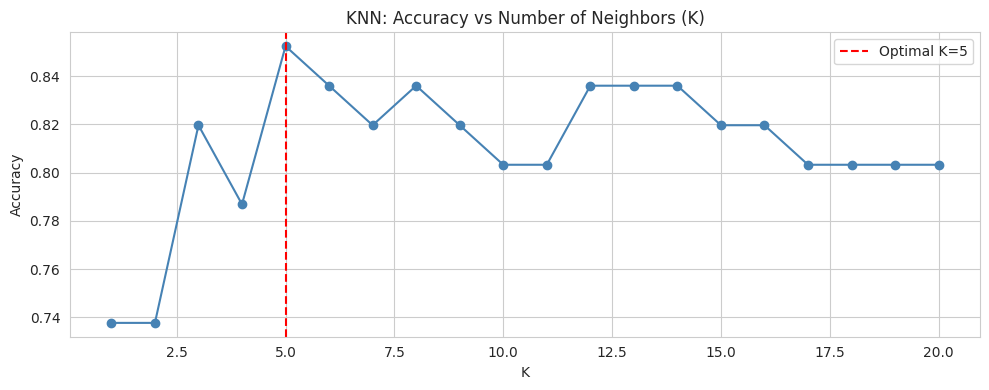

In [5]:
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    k_scores.append(knn.score(X_test_scaled, y_test))

optimal_k = k_range[k_scores.index(max(k_scores))]
print(f'Optimal K = {optimal_k}  |  Accuracy = {max(k_scores):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title('KNN: Accuracy vs Number of Neighbors (K)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Model Training and Evaluation
Phase 2 models:
- Naive Bayes
- Logistic Regression
- KNN Classifier
- SVM Classifier

Phase 1 baseline models included in comparison:
- Decision Tree
- AdaBoost

In [6]:
def evaluate_classifier(model, model_name, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ConfusionMatrix': confusion_matrix(y_test, y_pred)
    }
    return metrics

models = {
    'Decision Tree (Phase 1)': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'AdaBoost (Phase 1)': AdaBoostClassifier(random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'KNN Classifier': KNeighborsClassifier(n_neighbors=optimal_k),
    'SVM Classifier': SVC(kernel='rbf', C=1.0, gamma='scale')
}

results = []
for name, model in models.items():
    res = evaluate_classifier(model, name, X_train_scaled, X_test_scaled, y_train, y_test)
    results.append(res)

results_df = pd.DataFrame(results)
display(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']].sort_values(by='F1-score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-score
4,KNN Classifier,0.852459,0.815789,0.939394,0.873239
5,SVM Classifier,0.836066,0.780488,0.969697,0.864865
2,Naive Bayes,0.836066,0.794872,0.939394,0.861111
3,Logistic Regression,0.819672,0.775000,0.939394,0.849315
1,AdaBoost (Phase 1),0.786885,0.763158,0.878788,0.816901
0,Decision Tree (Phase 1),0.704918,0.702703,0.787879,0.742857


## 6. Confusion Matrix Heatmaps
Visualize confusion matrices for all models.

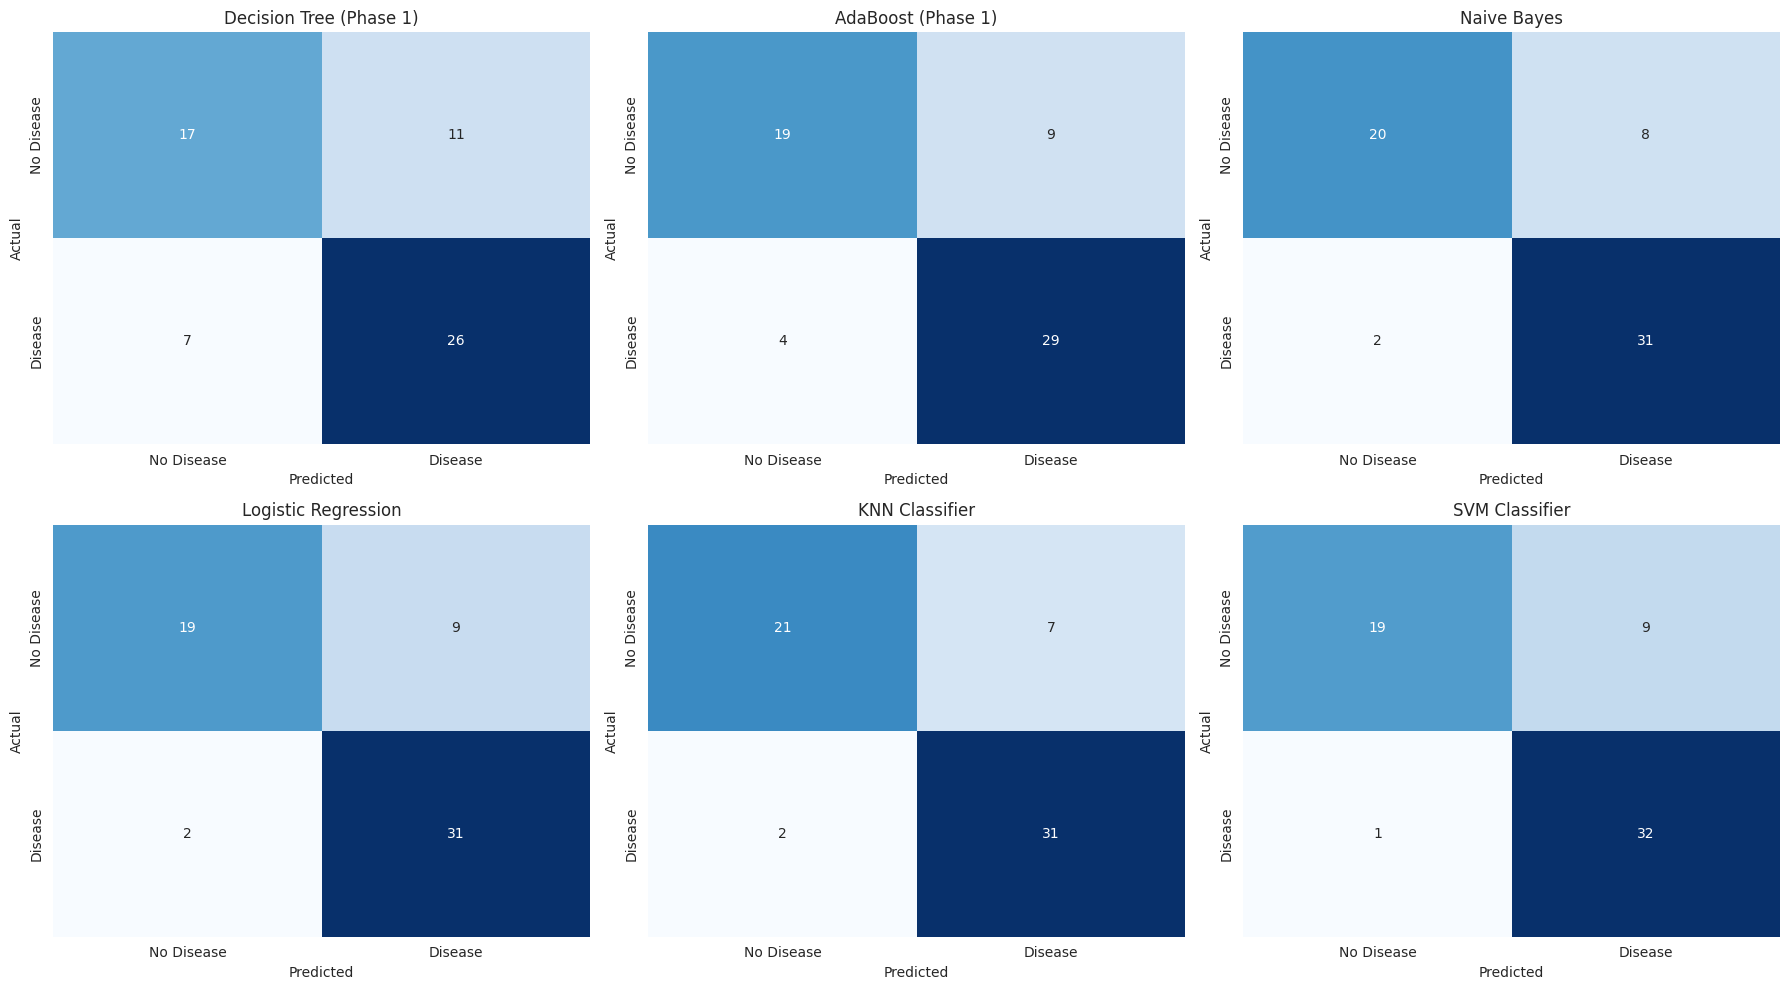

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, row in results_df.iterrows():
    sns.heatmap(
        row['ConfusionMatrix'],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[i],
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease']
    )
    axes[i].set_title(row['Model'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 7. Final Comparison Table
Final table with all classification metrics, sorted by F1-score.

In [8]:
final_classification_table = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']].copy()
final_classification_table = final_classification_table.sort_values(by='F1-score', ascending=False).reset_index(drop=True)
display(final_classification_table.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,KNN Classifier,0.8525,0.8158,0.9394,0.8732
1,SVM Classifier,0.8361,0.7805,0.9697,0.8649
2,Naive Bayes,0.8361,0.7949,0.9394,0.8611
3,Logistic Regression,0.8197,0.7750,0.9394,0.8493
4,AdaBoost (Phase 1),0.7869,0.7632,0.8788,0.8169
5,Decision Tree (Phase 1),0.7049,0.7027,0.7879,0.7429


## 8. All Metrics Comparison Chart
Grouped bar chart comparing Accuracy, Precision, Recall, and F1-score across all models.

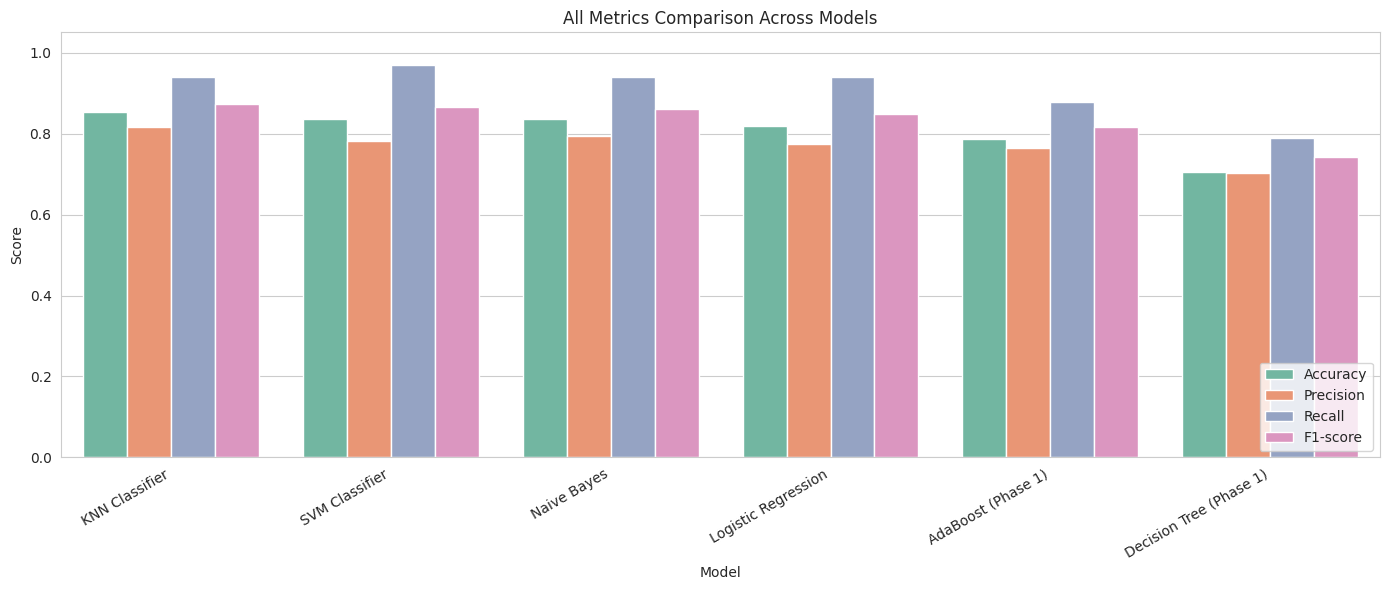

In [9]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score']
plot_data = final_classification_table.melt(
    id_vars='Model', value_vars=metrics_to_plot,
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_data, x='Model', y='Score', hue='Metric', palette='Set2')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.title('All Metrics Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Best Model and Conclusion
Select the best model based on F1-score.

In [10]:
best_row = final_classification_table.iloc[0]

print('Best Classification Model:')
print(f"Model: {best_row['Model']}")
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1-score: {best_row['F1-score']:.4f}")

print('\nConclusion:')
print('This model is selected as best because it has the highest F1-score,')
print('which indicates the best balance between precision and recall for this medical classification task.')

Best Classification Model:
Model: KNN Classifier
Accuracy: 0.8525
Precision: 0.8158
Recall: 0.9394
F1-score: 0.8732

Conclusion:
This model is selected as best because it has the highest F1-score,
which indicates the best balance between precision and recall for this medical classification task.
